<a href="https://colab.research.google.com/github/RAJANIKANT2907/Data-Science-Projects-and-Assignments/blob/main/MLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
uploaded = files.upload()

Saving ToyotaCorolla_-_MLR.csv to ToyotaCorolla_-_MLR.csv


Dataset Shape: (1436, 11)

First 5 rows:
   Price  Age_08_04     KM Fuel_Type  HP  Automatic    cc  Doors  Cylinders  \
0  13500         23  46986    Diesel  90          0  2000      3          4   
1  13750         23  72937    Diesel  90          0  2000      3          4   
2  13950         24  41711    Diesel  90          0  2000      3          4   
3  14950         26  48000    Diesel  90          0  2000      3          4   
4  13750         30  38500    Diesel  90          0  2000      3          4   

   Gears  Weight  
0      5    1165  
1      5    1165  
2      5    1165  
3      5    1165  
4      5    1170  

TASK 1: EDA & PREPROCESSING

Summary Statistics:
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350

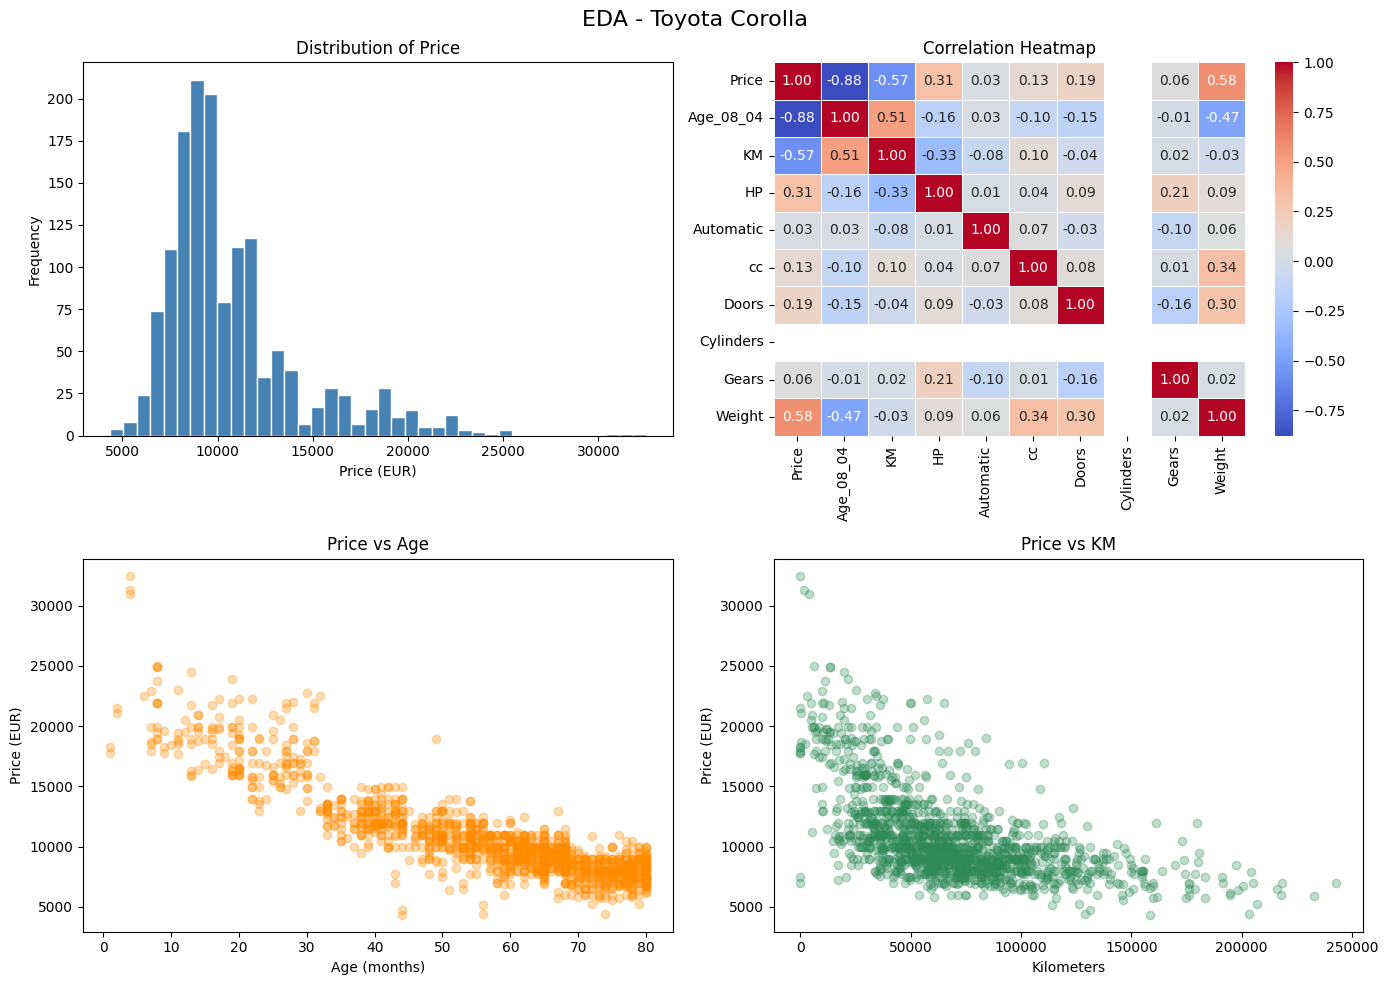


EDA plot saved as 'eda_plots.png'


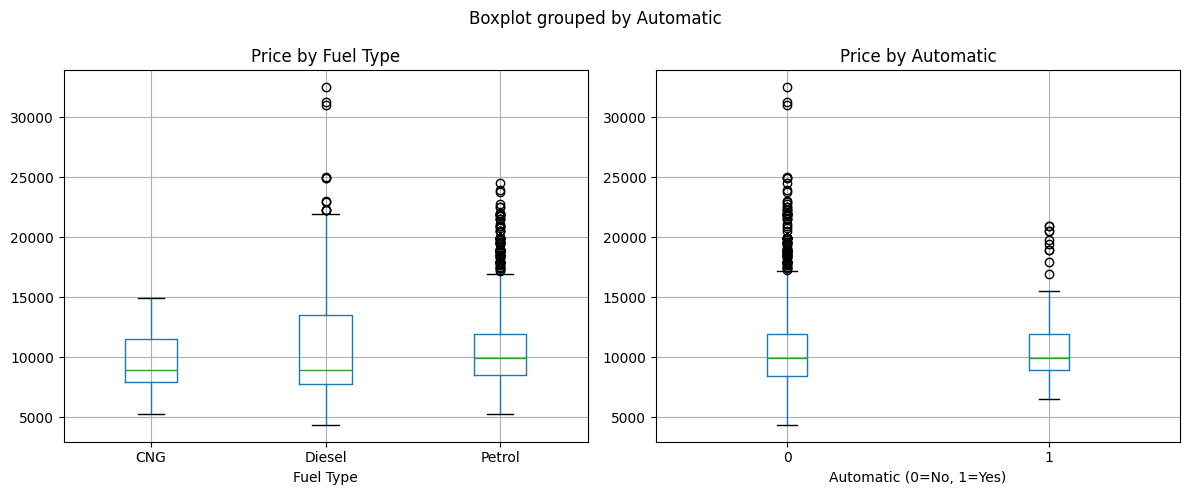

Boxplot saved as 'boxplots.png'

--- Preprocessing ---
Columns after encoding: ['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol']

Features shape: (1436, 11)
Target shape:   (1436,)

TASK 2: TRAIN-TEST SPLIT
Training set:   1148 samples
Testing  set:   288 samples

TASK 3: BUILDING MODELS

Model 1 - Full MLR (all features, unscaled)
  Train R²  : 0.8703
  Test  R²  : 0.8349
  Test  RMSE: 1484.27
  Test  MAE : 990.89

  Coefficients (Model 1):
         Feature   Coefficient
Fuel_Type_Petrol  1.370809e+03
           Gears  5.516007e+02
       Automatic  1.488309e+02
          Weight  2.588496e+01
              HP  1.403948e+01
       Cylinders -1.620037e-12
              KM -1.623141e-02
              cc -3.037219e-02
           Doors -6.031097e+01
Fuel_Type_Diesel -6.854876e+01
       Age_08_04 -1.208305e+02

Model 2 - MLR (top 5 correlated features)
  Train R²  : 0.8644
  Test  R²  : 0.8504
  Test  RMSE

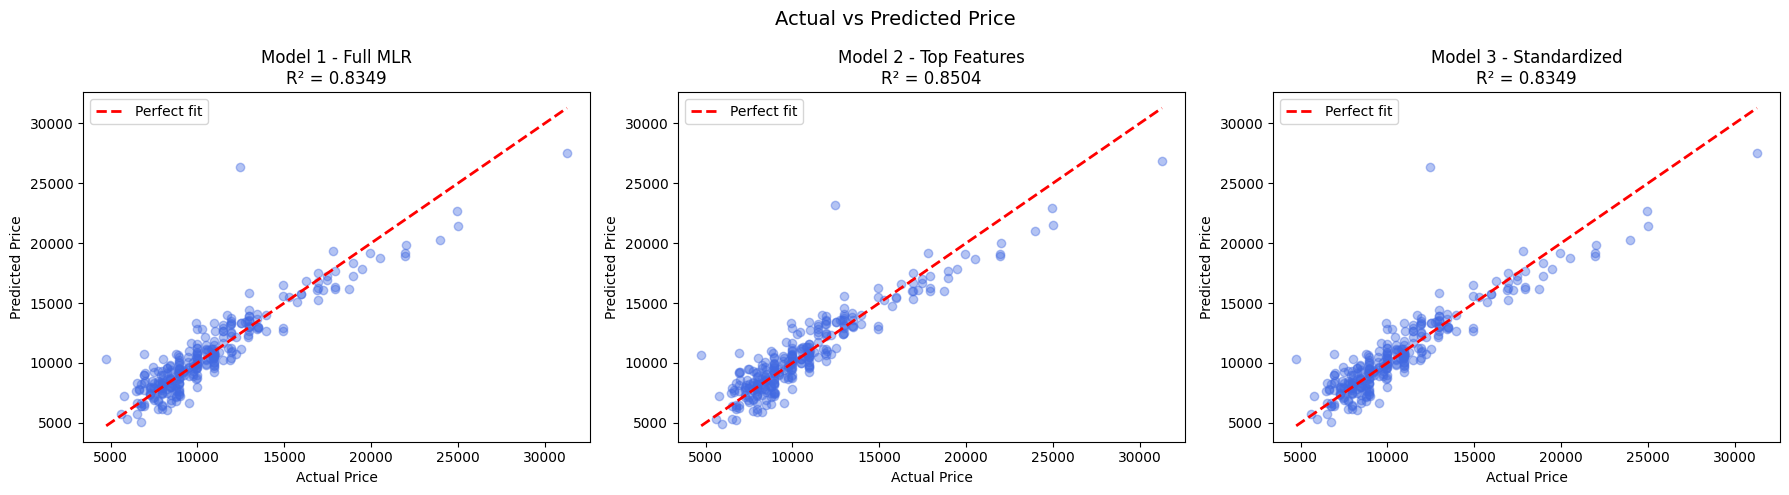

Saved 'actual_vs_predicted.png'

TASK 5: LASSO & RIDGE REGULARIZATION

Ridge Regression (alpha=1.0)
  Train R²  : 0.8703
  Test  R²  : 0.8350
  Test  RMSE: 1483.56
  Test  MAE : 990.86

Lasso Regression (alpha=50.0)
  Train R²  : 0.8688
  Test  R²  : 0.8426
  Test  RMSE: 1449.26
  Test  MAE : 994.23

  Lasso Coefficients (0 = feature eliminated):
         Feature  Lasso Coefficient
       Age_08_04       -2252.726439
              KM        -634.232429
              HP         252.300211
       Automatic           2.239938
              cc          -0.000000
           Doors          -0.000000
       Cylinders           0.000000
           Gears          69.894602
          Weight        1149.762500
Fuel_Type_Diesel          -0.000000
Fuel_Type_Petrol         307.034044

  Coefficient Comparison (standardized):
         Feature           OLS        Ridge        Lasso
       Age_08_04 -2.267295e+03 -2265.001345 -2252.726439
              KM -6.116544e+02  -613.359534  -634.232429
      

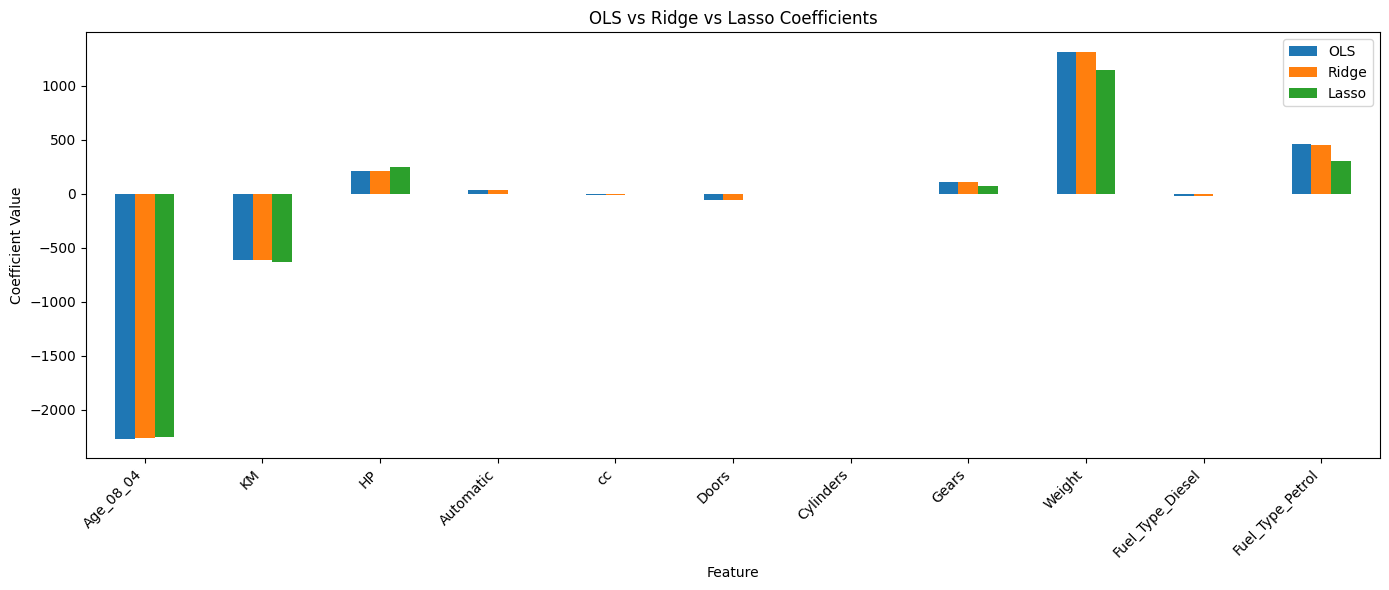

Saved 'coefficient_comparison.png'

--- Final Model Comparison ---
                     Model       R²
        Model 1 - Full MLR 0.834889
Model 2 - Top Features MLR 0.850409
Model 3 - Standardized MLR 0.834889
         Ridge (alpha=1.0) 0.835046
        Lasso (alpha=50.0) 0.842584

Done! All plots saved. See comments in code for interview answers.


In [8]:
# =============================================================================
# Multiple Linear Regression - Toyota Corolla Price Prediction
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv("ToyotaCorolla_-_MLR.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


# =============================================================================
# TASK 1: Exploratory Data Analysis (EDA) & Preprocessing
# =============================================================================

print("\n" + "="*60)
print("TASK 1: EDA & PREPROCESSING")
print("="*60)

# --- Summary Statistics ---
print("\nSummary Statistics:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

# --- EDA Visualizations ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA - Toyota Corolla", fontsize=16)

# 1. Distribution of Target Variable (Price)
axes[0, 0].hist(df["Price"], bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribution of Price")
axes[0, 0].set_xlabel("Price (EUR)")
axes[0, 0].set_ylabel("Frequency")

# 2. Correlation Heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 1], linewidths=0.5)
axes[0, 1].set_title("Correlation Heatmap")

# 3. Price vs Age
axes[1, 0].scatter(df["Age_08_04"], df["Price"], alpha=0.3, color="darkorange")
axes[1, 0].set_title("Price vs Age")
axes[1, 0].set_xlabel("Age (months)")
axes[1, 0].set_ylabel("Price (EUR)")

# 4. Price vs KM
axes[1, 1].scatter(df["KM"], df["Price"], alpha=0.3, color="seagreen")
axes[1, 1].set_title("Price vs KM")
axes[1, 1].set_xlabel("Kilometers")
axes[1, 1].set_ylabel("Price (EUR)")

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150)
plt.show()
print("\nEDA plot saved as 'eda_plots.png'")

# Box plots for categorical features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column="Price", by="Fuel_Type", ax=axes[0])
axes[0].set_title("Price by Fuel Type")
axes[0].set_xlabel("Fuel Type")
df.boxplot(column="Price", by="Automatic", ax=axes[1])
axes[1].set_title("Price by Automatic")
axes[1].set_xlabel("Automatic (0=No, 1=Yes)")
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150)
plt.show()
print("Boxplot saved as 'boxplots.png'")

# --- Preprocessing ---
print("\n--- Preprocessing ---")

# Encode categorical variable: Fuel_Type (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)
print("Columns after encoding:", df_encoded.columns.tolist())

# Drop duplicate/irrelevant columns if any
# 'Cylinders' and 'Gears' may be redundant — we'll keep them but note this

# Define features and target
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape:   {y.shape}")


# =============================================================================
# TASK 2: Train-Test Split (80% / 20%)
# =============================================================================

print("\n" + "="*60)
print("TASK 2: TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set:   {X_train.shape[0]} samples")
print(f"Testing  set:   {X_test.shape[0]} samples")

# Standardize features (important for Ridge/Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# =============================================================================
# TASK 3: Build Multiple Linear Regression Models
# =============================================================================

print("\n" + "="*60)
print("TASK 3: BUILDING MODELS")
print("="*60)

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model, evaluate on both sets, and print metrics."""
    model.fit(X_tr, y_tr)
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    train_r2   = r2_score(y_tr, y_pred_train)
    test_r2    = r2_score(y_te, y_pred_test)
    test_rmse  = np.sqrt(mean_squared_error(y_te, y_pred_test))
    test_mae   = mean_absolute_error(y_te, y_pred_test)

    print(f"\n{name}")
    print(f"  Train R²  : {train_r2:.4f}")
    print(f"  Test  R²  : {test_r2:.4f}")
    print(f"  Test  RMSE: {test_rmse:.2f}")
    print(f"  Test  MAE : {test_mae:.2f}")
    return model, y_pred_test, test_r2

# -------------------------------------------------------
# Model 1: Full MLR (all features, unscaled)
# -------------------------------------------------------
lr_full = LinearRegression()
lr_full, pred_full, r2_full = evaluate_model(
    "Model 1 - Full MLR (all features, unscaled)",
    lr_full, X_train, y_train, X_test, y_test
)

# Coefficients for Model 1
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_full.coef_
}).sort_values("Coefficient", ascending=False)
print("\n  Coefficients (Model 1):")
print(coef_df.to_string(index=False))

# -------------------------------------------------------
# Model 2: MLR with top correlated features only
# -------------------------------------------------------
top_features = ["Age_08_04", "KM", "HP", "Weight", "cc"]
X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

lr_top = LinearRegression()
lr_top, pred_top, r2_top = evaluate_model(
    "Model 2 - MLR (top 5 correlated features)",
    lr_top, X_train_top, y_train, X_test_top, y_test
)

# -------------------------------------------------------
# Model 3: MLR on standardized features
# -------------------------------------------------------
lr_scaled = LinearRegression()
lr_scaled, pred_scaled, r2_scaled = evaluate_model(
    "Model 3 - MLR (all features, standardized)",
    lr_scaled, X_train_scaled, y_train, X_test_scaled, y_test
)


# =============================================================================
# TASK 4: Performance Evaluation
# =============================================================================

print("\n" + "="*60)
print("TASK 4: PERFORMANCE EVALUATION SUMMARY")
print("="*60)

results = {
    "Model 1 - Full MLR":    {"R²": r2_full,   "Predictions": pred_full},
    "Model 2 - Top Features": {"R²": r2_top,    "Predictions": pred_top},
    "Model 3 - Standardized": {"R²": r2_scaled, "Predictions": pred_scaled},
}

# Actual vs Predicted plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Actual vs Predicted Price", fontsize=14)
for ax, (name, info) in zip(axes, results.items()):
    ax.scatter(y_test, info["Predictions"], alpha=0.4, color="royalblue")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            "r--", lw=2, label="Perfect fit")
    ax.set_title(f"{name}\nR² = {info['R²']:.4f}")
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()
print("Saved 'actual_vs_predicted.png'")


# =============================================================================
# TASK 5: Lasso and Ridge Regression
# =============================================================================

print("\n" + "="*60)
print("TASK 5: LASSO & RIDGE REGULARIZATION")
print("="*60)

# --- Ridge Regression ---
ridge = Ridge(alpha=1.0)  # alpha is the regularization strength (lambda)
ridge, pred_ridge, r2_ridge = evaluate_model(
    "Ridge Regression (alpha=1.0)",
    ridge, X_train_scaled, y_train, X_test_scaled, y_test
)

# --- Lasso Regression ---
lasso = Lasso(alpha=50.0, max_iter=10000)  # higher alpha forces more sparsity
lasso, pred_lasso, r2_lasso = evaluate_model(
    "Lasso Regression (alpha=50.0)",
    lasso, X_train_scaled, y_train, X_test_scaled, y_test
)

# Show which features Lasso zeroed out
lasso_coef = pd.DataFrame({
    "Feature": X.columns,
    "Lasso Coefficient": lasso.coef_
})
print("\n  Lasso Coefficients (0 = feature eliminated):")
print(lasso_coef.to_string(index=False))

# --- Compare coefficients: OLS vs Ridge vs Lasso ---
coef_comparison = pd.DataFrame({
    "Feature":  X.columns,
    "OLS":      lr_scaled.coef_,
    "Ridge":    ridge.coef_,
    "Lasso":    lasso.coef_
})
print("\n  Coefficient Comparison (standardized):")
print(coef_comparison.to_string(index=False))

# Bar chart comparison
coef_comparison.set_index("Feature").plot(kind="bar", figsize=(14, 6))
plt.title("OLS vs Ridge vs Lasso Coefficients")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("coefficient_comparison.png", dpi=150)
plt.show()
print("Saved 'coefficient_comparison.png'")

# Final summary table
print("\n--- Final Model Comparison ---")
summary = pd.DataFrame([
    {"Model": "Model 1 - Full MLR",        "R²": r2_full},
    {"Model": "Model 2 - Top Features MLR", "R²": r2_top},
    {"Model": "Model 3 - Standardized MLR", "R²": r2_scaled},
    {"Model": "Ridge (alpha=1.0)",          "R²": r2_ridge},
    {"Model": "Lasso (alpha=50.0)",         "R²": r2_lasso},
])
print(summary.to_string(index=False))


# =============================================================================
# INTERVIEW QUESTIONS ANSWERS (as comments)
# =============================================================================

"""
Q1: What is Normalization & Standardization and how is it helpful?

- Normalization (Min-Max Scaling): Rescales values to a [0, 1] range.
  Formula: x' = (x - x_min) / (x_max - x_min)
  Useful when you need bounded outputs or features on different scales.

- Standardization (Z-score Scaling): Rescales to mean=0, std=1.
  Formula: x' = (x - mean) / std
  Preferred for linear models, Ridge, and Lasso because these are
  sensitive to feature magnitude — without it, features with larger
  ranges dominate the coefficients unfairly.

Q2: What techniques can be used to address multicollinearity?

1. Remove one of the correlated features (feature selection).
2. Use Principal Component Analysis (PCA) to create orthogonal components.
3. Apply Ridge Regression — it shrinks correlated coefficients together
   rather than inflating them.
4. Use Variance Inflation Factor (VIF) to detect and prune multicollinear
   predictors (VIF > 10 is a common threshold for concern).
5. Collect more data, if possible, to reduce variance in estimates.
"""

print("\nDone! All plots saved. See comments in code for interview answers.")